In [ ]:
                                                                                                            import pandas as pd
data = pd.read_csv('/content/Copy of balanced_blackhole.csv')
data

,time,source,destination,length,info,transmission_rate_per_1000_ms,reception_rate_per_1000_ms,transmission_average_per_sec,reception_average_per_sec,transmission_count_per_sec,reception_count_per_sec,transmission_total_duration_per_sec,reception_total_duration_per_sec,dao,dis,dio,category,label
0,0.037,39,9999,0.0,1.0,0.000000,0.671176,0.000000,0.499879,0.000000,0.671176,0.539313,0.570032,0.0,0.0,0.000000,Normal,0.0
1,0.037,39,9999,0.0,1.0,0.000000,0.649873,0.000000,0.505234,0.000000,0.649873,0.264704,0.530547,0.0,0.0,0.000000,Normal,0.0
2,0.038,39,9999,0.0,1.0,0.671176,0.652361,0.462516,0.501327,0.671768,0.652361,0.546376,1.000000,0.0,0.0,0.690115,Blackhole,1.0
3,0.045,39,9999,0.0,1.0,0.000000,0.633786,0.000000,0.517346,0.000000,0.634105,0.585425,0.553276,0.0,0.0,0.000000,Normal,0.0
4,0.046,39,9999,0.0,1.0,0.000000,0.630378,0.000000,0.538789,0.000000,0.630378,0.443171,0.615377,0.0,0.0,0.000000,Normal,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16390,21.453,25,9999,0.0,1.0,0.619444,0.646704,0.478869,0.511003,0.619705,0.646704,0.540233,0.550485,0.0,0.0,0.663504,Normal,0.0
16391,21.453,78,9999,0.0,1.0,0.000000,0.776751,0.000000,0.487782,0.000000,0.769910,0.442595,0.624850,0.0,0.0,0.000000,Normal,0.0
16392,21.454,97,9999,0.0,1.0,0.526763,0.776751,0.532578,0.487782,0.526763,0.769910,0.426945,0.624850,0.0,0.0,0.641871,Normal,0.0
16393,21.454,97,9999,0.0,1.0,0.520668,0.646704,0.483879,0.511003,0.520915,0.646704,0.356680,0.550485,0.0,0.0,0.632217,Normal,0.0


**Optimized Ensemble(RF+GB) Federated Learning**

---[link text](https://)

**Gridsearch + one new**

**Ensemble Horizontal FL**

Accuracy: 0.9813
Precision: 0.9446
Recall: 1.0000
F1 Score: 0.9715


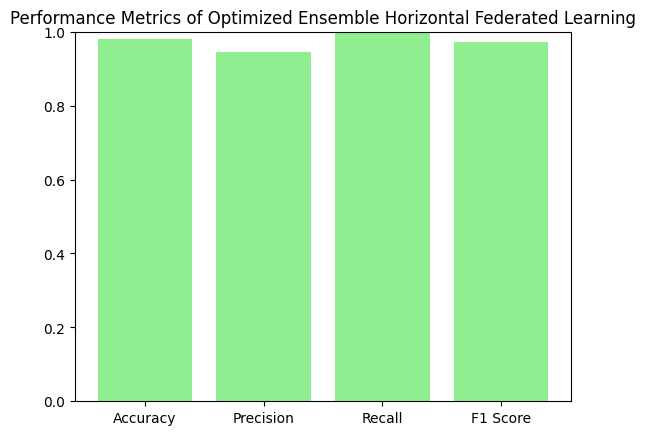

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt
import joblib  # For saving and loading models

# Load the dataset
data = pd.read_csv('/content/blackhole.csv')

# Data preprocessing
X = data.drop(columns=['category','label'])  # Features
y = data['label']  # Target variable

# Handling missing values in features and target
imputer = SimpleImputer(strategy='mean')
X = imputer.fit_transform(X)
y = imputer.fit_transform(y.values.reshape(-1, 1)).ravel()  # Impute missing values in target

# Convert target to integers
y = y.astype(int)

# Splitting data into federated clients (simulating 2 clients)
X1, X2, y1, y2 = train_test_split(X, y, test_size=0.3, random_state=42)

# Standardize the data
scaler = StandardScaler()
X1 = scaler.fit_transform(X1)
X2 = scaler.transform(X2)  # Ensure using the same scaler

# Hyperparameter grids for GridSearch
rf_params = {
    'n_estimators': [15, 20, 30],
    'max_depth': [None, 6, 6],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'random_state': [40, 48, 58]  # Added different random states for robustness
}
gb_params = {
    'n_estimators': [10, 20, 30],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 3, 3],
    'random_state': [40, 48, 58]  # Added different random states for robustness
}

# Initialize models
rf_model = RandomForestClassifier(random_state=42)
gb_model = GradientBoostingClassifier(random_state=42)

# GridSearchCV for thorough optimization
rf_grid1 = GridSearchCV(rf_model, rf_params, cv=3, scoring='accuracy', n_jobs=-1)
gb_grid1 = GridSearchCV(gb_model, gb_params, cv=3, scoring='accuracy', n_jobs=-1)

rf_grid2 = GridSearchCV(rf_model, rf_params, cv=3, scoring='accuracy', n_jobs=-1)
gb_grid2 = GridSearchCV(gb_model, gb_params, cv=3, scoring='accuracy', n_jobs=-1)

# Fit models on each client's data
rf_grid1.fit(X1, y1)
gb_grid1.fit(X1, y1)

rf_grid2.fit(X2, y2)
gb_grid2.fit(X2, y2)

# Best models after GridSearchCV
rf_best1 = rf_grid1.best_estimator_
gb_best1 = gb_grid1.best_estimator_

rf_best2 = rf_grid2.best_estimator_
gb_best2 = gb_grid2.best_estimator_

# Predict probabilities for models
y_pred_prob_rf1 = rf_best1.predict_proba(X1)[:, 1]
y_pred_prob_gb1 = gb_best1.predict_proba(X1)[:, 1]

y_pred_prob_rf2 = rf_best2.predict_proba(X2)[:, 1]
y_pred_prob_gb2 = gb_best2.predict_proba(X2)[:, 1]

# Combine predictions using averaging
y_pred_ensemble1 = (y_pred_prob_rf1 + y_pred_prob_gb1) / 2
y_pred_ensemble2 = (y_pred_prob_rf2 + y_pred_prob_gb2) / 2

# Threshold the combined prediction to classify
y_pred_final1 = (y_pred_ensemble1 > 0.2).astype(int)  # Adjust threshold if needed
y_pred_final2 = (y_pred_ensemble2 > 0.2).astype(int)  # Adjust threshold if needed

# Combine predictions and ground truth from both clients
y_true_combined = np.concatenate([y1, y2])
y_pred_combined = np.concatenate([y_pred_final1, y_pred_final2])

# Calculate performance metrics
accuracy = accuracy_score(y_true_combined, y_pred_combined)
precision = precision_score(y_true_combined, y_pred_combined)
recall = recall_score(y_true_combined, y_pred_combined)
f1 = f1_score(y_true_combined, y_pred_combined)

# Print results
print(f'Accuracy: {accuracy:.4f}')
print(f'Precision: {precision:.4f}')
print(f'Recall: {recall:.4f}')
print(f'F1 Score: {f1:.4f}')

# Plotting the results
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
scores = [accuracy, precision, recall, f1]

plt.bar(metrics, scores, color='lightgreen')
plt.ylim(0, 1)
plt.title('Performance Metrics of Optimized Ensemble Horizontal Federated Learning')
plt.show()

**Ensemble Vertical FL**

Accuracy: 0.9553
Precision: 0.8767
Recall: 1.0000
F1 Score: 0.9343


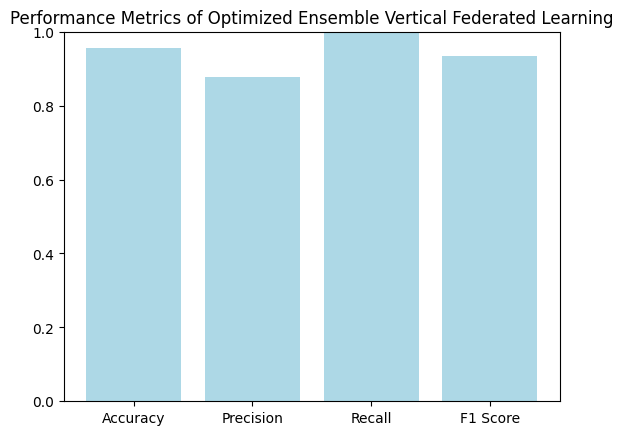

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt
import joblib  # For saving and loading models

# Load the dataset
# data = pd.read_csv('/content/balanced_blackhole.csv')

# Data preprocessing
X = data.drop(columns=['category', 'label'])  # Features
y = data['label']  # Target variable

# Handling missing values in features and target
imputer = SimpleImputer(strategy='mean')
X = imputer.fit_transform(X)
y = imputer.fit_transform(y.values.reshape(-1, 1)).ravel()  # Impute missing values in target

# Convert target to integers
y = y.astype(int)

# Splitting data vertically by features for federated clients (simulating 2 clients)
split_index = X.shape[1] // 2  # Split halfway
X1, X2 = X[:, :split_index], X[:, split_index:]  # Client 1 gets first half, Client 2 gets second half

# Standardize the data for both clients
scaler1 = StandardScaler()
X1 = scaler1.fit_transform(X1)

scaler2 = StandardScaler()
X2 = scaler2.fit_transform(X2)

# Hyperparameter grids for GridSearch
rf_params = {
    'n_estimators': [15, 20, 30],
    'max_depth': [None, 9, 8],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'random_state': [42, 50, 60]  # Added different random states for robustness
}
gb_params = {
    'n_estimators': [15, 25, 35],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [6, 5, 5],
    'random_state': [42, 50, 60]  # Added different random states for robustness
}

# Initialize models
rf_model = RandomForestClassifier(random_state=42)
gb_model = GradientBoostingClassifier(random_state=42)

# GridSearchCV for thorough optimization for each client
rf_grid1 = GridSearchCV(rf_model, rf_params, cv=3, scoring='accuracy', n_jobs=-1)
gb_grid1 = GridSearchCV(gb_model, gb_params, cv=3, scoring='accuracy', n_jobs=-1)

rf_grid2 = GridSearchCV(rf_model, rf_params, cv=3, scoring='accuracy', n_jobs=-1)
gb_grid2 = GridSearchCV(gb_model, gb_params, cv=3, scoring='accuracy', n_jobs=-1)

# Fit models on each client's data (X1 for client 1 and X2 for client 2)
rf_grid1.fit(X1, y)
gb_grid1.fit(X1, y)

rf_grid2.fit(X2, y)
gb_grid2.fit(X2, y)

# Best models after GridSearchCV
rf_best1 = rf_grid1.best_estimator_
gb_best1 = gb_grid1.best_estimator_

rf_best2 = rf_grid2.best_estimator_
gb_best2 = gb_grid2.best_estimator_

# Predict probabilities for models (since features are different, both use same labels)
y_pred_prob_rf1 = rf_best1.predict_proba(X1)[:, 1]
y_pred_prob_gb1 = gb_best1.predict_proba(X1)[:, 1]

y_pred_prob_rf2 = rf_best2.predict_proba(X2)[:, 1]
y_pred_prob_gb2 = gb_best2.predict_proba(X2)[:, 1]

# Combine predictions using averaging
y_pred_ensemble1 = (y_pred_prob_rf1 + y_pred_prob_gb1) / 2
y_pred_ensemble2 = (y_pred_prob_rf2 + y_pred_prob_gb2) / 2

# Final prediction combining both clients' predictions
y_pred_final = (y_pred_ensemble1 + y_pred_ensemble2) / 2

# Threshold the combined prediction to classify
y_pred_final_class = (y_pred_final > 0.2).astype(int)  # Adjust threshold if needed

# Calculate performance metrics
accuracy = accuracy_score(y, y_pred_final_class)
precision = precision_score(y, y_pred_final_class)
recall = recall_score(y, y_pred_final_class)
f1 = f1_score(y, y_pred_final_class)

# Print results
print(f'Accuracy: {accuracy:.4f}')
print(f'Precision: {precision:.4f}')
print(f'Recall: {recall:.4f}')
print(f'F1 Score: {f1:.4f}')

# Plotting the results
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
scores = [accuracy, precision, recall, f1]

plt.bar(metrics, scores, color='lightblue')
plt.ylim(0, 1)
plt.title('Performance Metrics of Optimized Ensemble Vertical Federated Learning')
plt.show()

**Ensemble Hybrid FL**

Accuracy: 0.9469
Precision: 0.8669
Recall: 1.0000
F1 Score: 0.9287


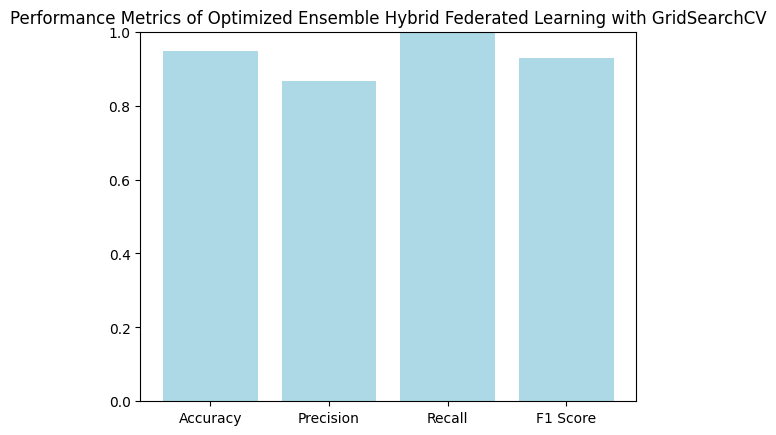

In [14]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from joblib import Parallel, delayed
import matplotlib.pyplot as plt

# Load the dataset
# data = pd.read_csv('/content/blackhole.csv')

# Data preprocessing
X = data.drop(columns=['category', 'label'])  # Features
y = data['label']  # Target variable

# Handling missing values
imputer = SimpleImputer(strategy='mean')
X = imputer.fit_transform(X)
y = np.array(y).reshape(-1, 1)
y = imputer.fit_transform(y).ravel()  # Impute missing values in target

# Convert target to integers
y = y.astype(int)

# Split data for hybrid federated learning
X_train_full, X_test, y_train_full, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Further split training data into two parts for horizontal split
X_train1, X_train2, y_train1, y_train2 = train_test_split(X_train_full, y_train_full, test_size=0.5, random_state=42)

# Standardize the data
scaler = StandardScaler()
X_train1 = scaler.fit_transform(X_train1)
X_train2 = scaler.transform(X_train2)
X_test = scaler.transform(X_test)

# Hyperparameter grid for RandomForest
rf_params = {
    'n_estimators': [15, 25, 50],
    'max_depth': [6, 6, 7],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'random_state': [42, 50, 60]        # Added different random states for robustness
}

# Hyperparameter grid for GradientBoosting
gb_params = {
    'n_estimators': [30, 50],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [4, 4, 5],
    'random_state': [42, 50, 60]        # Added different random states for robustness
}

# Function to train RandomForest using GridSearchCV
def train_rf_with_gridsearch(X, y):
    rf_model = RandomForestClassifier(random_state=42)
    grid_search = GridSearchCV(estimator=rf_model, param_grid=rf_params, cv=3, n_jobs=-1)
    grid_search.fit(X, y)
    return grid_search.best_estimator_

# Function to train GradientBoosting using GridSearchCV
def train_gb_with_gridsearch(X, y):
    gb_model = GradientBoostingClassifier(random_state=42)
    grid_search = GridSearchCV(estimator=gb_model, param_grid=gb_params, cv=3, n_jobs=-1)
    grid_search.fit(X, y)
    return grid_search.best_estimator_

# Parallelize model training for horizontal federated learning
results = Parallel(n_jobs=2)([
    delayed(train_rf_with_gridsearch)(X_train1, y_train1),
    delayed(train_rf_with_gridsearch)(X_train2, y_train2),
    delayed(train_gb_with_gridsearch)(X_train1, y_train1),
    delayed(train_gb_with_gridsearch)(X_train2, y_train2),
])

rf_model1, rf_model2, gb_model1, gb_model2 = results

# Predict probabilities for horizontal models
y_pred_prob_rf1 = rf_model1.predict_proba(X_test)[:, 1]
y_pred_prob_gb1 = gb_model1.predict_proba(X_test)[:, 1]
y_pred_prob_rf2 = rf_model2.predict_proba(X_test)[:, 1]
y_pred_prob_gb2 = gb_model2.predict_proba(X_test)[:, 1]

# Combine predictions from horizontal federated learning
y_pred_ensemble_horizontal = (y_pred_prob_rf1 + y_pred_prob_gb1 + y_pred_prob_rf2 + y_pred_prob_gb2) / 4

# Initialize and fit the vertical federated model with GridSearchCV
rf_model_vertical = train_rf_with_gridsearch(X_train_full, y_train_full)
gb_model_vertical = train_gb_with_gridsearch(X_train_full, y_train_full)

# Predict probabilities for vertical models
y_pred_prob_rf_vertical = rf_model_vertical.predict_proba(X_test)[:, 1]
y_pred_prob_gb_vertical = gb_model_vertical.predict_proba(X_test)[:, 1]

# Combine predictions from vertical federated learning
y_pred_ensemble_vertical = (y_pred_prob_rf_vertical + y_pred_prob_gb_vertical) / 2

# Hybrid model: Combine horizontal and vertical federated learning predictions
y_pred_ensemble_hybrid = (y_pred_ensemble_horizontal + y_pred_ensemble_vertical) / 2

# Threshold the combined prediction to classify
y_pred_final = (y_pred_ensemble_hybrid > 0.3).astype(int)

# Calculate performance metrics
accuracy = accuracy_score(y_test, y_pred_final)
precision = precision_score(y_test, y_pred_final)
recall = recall_score(y_test, y_pred_final)
f1 = f1_score(y_test, y_pred_final)

# Print results
print(f'Accuracy: {accuracy:.4f}')
print(f'Precision: {precision:.4f}')
print(f'Recall: {recall:.4f}')
print(f'F1 Score: {f1:.4f}')

# Plotting the results
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
scores = [accuracy, precision, recall, f1]

plt.bar(metrics, scores, color='lightblue')
plt.ylim(0, 1)
plt.title('Performance Metrics of Optimized Ensemble Hybrid Federated Learning with GridSearchCV')
plt.show()
